In [ ]:
!pip install requests pandas nltk seaborn matplotlib
!pip install streamlit plotly pyarrow

# Setup and imports

In [1]:
import os, time, re, json, pickle
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

pd.set_option("display.max_columns", 100)
sns.set(style="whitegrid")
print("Setup complete.")

Setup complete.


# Fetch reviews via SerpApi

In [ ]:
import requests
import pandas as pd
import time

# --- Configuration ---
API_KEY   = "6feb1ba3c1dbb450427823b6336cd6a82a246c7b56d4283bb3696f003454f8d2"
PLACE_ID  = "ChIJLU7jZClu5kcR4PcOOO6p3I0"
MAX_REVIEWS = 2000
BASE_URL = "https://serpapi.com/search.json"

# --- Fetch function with error handling ---
def fetch_reviews_page(token=None, retries=3):
    params = {
        "engine": "google_maps_reviews",
        "place_id": PLACE_ID,
        "hl": "en",
        "api_key": API_KEY
    }
    if token:
        params["next_page_token"] = token

    for attempt in range(retries):
        try:
            response = requests.get(BASE_URL, params=params, timeout=30)
            response.raise_for_status()
            return response.json()
        except requests.exceptions.RequestException as e:
            print(f"⚠️ Attempt {attempt+1} failed: {e}")
            time.sleep(2)
    print("❌ All retries failed. Skipping this page.")
    return {}

# --- Main loop ---
reviews, token = [], None

while len(reviews) < MAX_REVIEWS:
    resp = fetch_reviews_page(token)
    batch = resp.get("reviews", [])
    if not batch:
        print("🛑 No more reviews found. Ending fetch.")
        break

    reviews += batch[:MAX_REVIEWS - len(reviews)]
    print(f"✅ Fetched {len(reviews)} reviews so far...")

    token = resp.get("serpapi_pagination", {}).get("next_page_token")
    if not token:
        print("✅ No next page token. Fetch complete.")
        break

    time.sleep(2)  # Respect SerpApi rate limits

# --- Convert to DataFrame ---
df = pd.DataFrame(reviews)
print(f"\n✅ Final count: {len(df)} reviews. Shape: {df.shape}")
df.head()

✅ Fetched 8 reviews so far...
✅ Fetched 18 reviews so far...
✅ Fetched 28 reviews so far...
✅ Fetched 38 reviews so far...
✅ Fetched 48 reviews so far...
✅ Fetched 58 reviews so far...
✅ Fetched 68 reviews so far...
✅ Fetched 78 reviews so far...
✅ Fetched 88 reviews so far...
✅ Fetched 98 reviews so far...
✅ Fetched 108 reviews so far...
✅ Fetched 118 reviews so far...
✅ Fetched 128 reviews so far...
✅ Fetched 138 reviews so far...
✅ Fetched 148 reviews so far...
✅ Fetched 158 reviews so far...
✅ Fetched 168 reviews so far...
✅ Fetched 178 reviews so far...
✅ Fetched 188 reviews so far...
✅ Fetched 198 reviews so far...
✅ Fetched 208 reviews so far...
✅ Fetched 218 reviews so far...
✅ Fetched 228 reviews so far...
✅ Fetched 238 reviews so far...
✅ Fetched 248 reviews so far...
✅ Fetched 258 reviews so far...
✅ Fetched 268 reviews so far...
✅ Fetched 278 reviews so far...
✅ Fetched 288 reviews so far...
✅ Fetched 298 reviews so far...
✅ Fetched 308 reviews so far...
✅ Fetched 318 revie

,link,rating,date,iso_date,iso_date_of_last_edit,images,source,review_id,user,snippet,extracted_snippet,details
0,https://www.google.com/maps/reviews/data=!4m8!...,5.0,4 weeks ago,2025-10-22T08:11:40Z,2025-10-22T08:11:40Z,[https://lh3.googleusercontent.com/geougc-cs/A...,Google,Ci9DQUlRQUNvZENodHljRjlvT25wMU0zQmhMVmgzZURCc2...,"{'name': 'Amrit Das', 'link': 'https://www.goo...",•\tNo ticket needed: You don’t have to buy a t...,{'original': '• No ticket needed: You don’t ha...,"{'visited_on': 'Weekday', 'wait_time': 'No wai..."
1,https://www.google.com/maps/reviews/data=!4m8!...,5.0,2 weeks ago,2025-11-05T16:00:26Z,2025-11-05T16:00:26Z,[https://lh3.googleusercontent.com/geougc-cs/A...,Google,Ci9DQUlRQUNvZENodHljRjlvT25SWVh6UnJja1JWWkRjM2...,"{'name': 'Arunbhaarat', 'link': 'https://www.g...",The Eiffel Tower is one of the most iconic lan...,{'original': 'The Eiffel Tower is one of the m...,"{'visited_on': 'Weekend', 'wait_time': '10–30 ..."
2,https://www.google.com/maps/reviews/data=!4m8!...,5.0,Edited a week ago,2025-10-26T23:38:48Z,2025-11-08T13:04:20Z,[https://lh3.googleusercontent.com/geougc-cs/A...,Google,Ci9DQUlRQUNvZENodHljRjlvT2pkelpHSjJjV3BxYkZaU1...,"{'name': 'Jay Kothari', 'link': 'https://www.g...",Great view from the top (actually 2nd floor is...,{'original': 'Great view from the top (actuall...,"{'visited_on': 'Weekday', 'wait_time': 'Up to ..."
3,https://www.google.com/maps/reviews/data=!4m8!...,5.0,a month ago,2025-10-02T20:41:44Z,2025-10-03T12:48:26Z,[https://lh3.googleusercontent.com/geougc-cs/A...,Google,Ci9DQUlRQUNvZENodHljRjlvT2pWcFNYVldZMFJ3YTNkVV...,"{'name': 'Aryan Patel', 'link': 'https://www.g...",A Magical Day at the Eiffel Tower\n\nI visited...,{'original': 'A Magical Day at the Eiffel Towe...,"{'visited_on': 'Weekday', 'wait_time': '30–60 ..."
4,https://www.google.com/maps/reviews/data=!4m8!...,5.0,Edited 2 weeks ago,2025-10-23T18:08:35Z,2025-11-03T13:45:14Z,[https://lh3.googleusercontent.com/geougc-cs/A...,Google,Ci9DQUlRQUNvZENodHljRjlvT25SdFRtcHpaREF5YlRob0...,"{'name': 'Jesika Downs', 'link': 'https://www....",What a beautiful view. Going to the top was am...,{'original': 'What a beautiful view. Going to ...,"{'visited_on': 'Weekday', 'wait_time': '10–30 ..."


In [7]:
df.to_excel("reviews.xlsx", index=False)

# Save raw reviews to pickle

In [6]:
with open("reviews.pkl", "wb") as f:
    pickle.dump(df, f)
print("Saved reviews.pkl")

# Example reload
with open("reviews.pkl", "rb") as f:
    df_loaded = pickle.load(f)
print("Reloaded pickle. Shape:", df_loaded.shape)

Saved reviews.pkl
Reloaded pickle. Shape: (2000, 12)


In [1]:
#Read the RAW file

import pandas as pd

df_raw = pd.read_excel("reviews.xlsx")
print(f"Loaded rows: {len(df_raw)}")
df_raw.head()

Loaded rows: 2000


,link,rating,date,iso_date,iso_date_of_last_edit,images,source,review_id,user,snippet,extracted_snippet,details
0,https://www.google.com/maps/reviews/data=!4m8!...,5,4 weeks ago,2025-10-22T08:11:40Z,2025-10-22T08:11:40Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,Ci9DQUlRQUNvZENodHljRjlvT25wMU0zQmhMVmgzZURCc2...,"{'name': 'Amrit Das', 'link': 'https://www.goo...",•\tNo ticket needed: You don’t have to buy a t...,{'original': '•\tNo ticket needed: You don’t h...,"{'visited_on': 'Weekday', 'wait_time': 'No wai..."
1,https://www.google.com/maps/reviews/data=!4m8!...,5,2 weeks ago,2025-11-05T16:00:26Z,2025-11-05T16:00:26Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,Ci9DQUlRQUNvZENodHljRjlvT25SWVh6UnJja1JWWkRjM2...,"{'name': 'Arunbhaarat', 'link': 'https://www.g...",The Eiffel Tower is one of the most iconic lan...,{'original': 'The Eiffel Tower is one of the m...,"{'visited_on': 'Weekend', 'wait_time': '10–30 ..."
2,https://www.google.com/maps/reviews/data=!4m8!...,5,Edited a week ago,2025-10-26T23:38:48Z,2025-11-08T13:04:20Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,Ci9DQUlRQUNvZENodHljRjlvT2pkelpHSjJjV3BxYkZaU1...,"{'name': 'Jay Kothari', 'link': 'https://www.g...",Great view from the top (actually 2nd floor is...,"{'original': ""Great view from the top (actuall...","{'visited_on': 'Weekday', 'wait_time': 'Up to ..."
3,https://www.google.com/maps/reviews/data=!4m8!...,5,a month ago,2025-10-02T20:41:44Z,2025-10-03T12:48:26Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,Ci9DQUlRQUNvZENodHljRjlvT2pWcFNYVldZMFJ3YTNkVV...,"{'name': 'Aryan Patel', 'link': 'https://www.g...",A Magical Day at the Eiffel Tower\n\nI visited...,{'original': 'A Magical Day at the Eiffel Towe...,"{'visited_on': 'Weekday', 'wait_time': '30–60 ..."
4,https://www.google.com/maps/reviews/data=!4m8!...,5,Edited 2 weeks ago,2025-10-23T18:08:35Z,2025-11-03T13:45:14Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,Ci9DQUlRQUNvZENodHljRjlvT25SdFRtcHpaREF5YlRob0...,"{'name': 'Jesika Downs', 'link': 'https://www....",What a beautiful view. Going to the top was am...,{'original': 'What a beautiful view. Going to ...,"{'visited_on': 'Weekday', 'wait_time': '10–30 ..."


In [3]:
# Inspect columns
print("Columns:", list(df_raw.columns))
df_raw.sample(3)

Columns: ['link', 'rating', 'date', 'iso_date', 'iso_date_of_last_edit', 'images', 'source', 'review_id', 'user', 'snippet', 'extracted_snippet', 'details']


,link,rating,date,iso_date,iso_date_of_last_edit,images,source,review_id,user,snippet,extracted_snippet,details
932,https://www.google.com/maps/reviews/data=!4m8!...,5,6 months ago,2025-05-08T10:49:03Z,2025-05-08T10:50:08Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,ChZDSUhNMG9nS0VNLVZrWXExc3FUZGZ3EAE,"{'name': 'Malak Chhimi', 'link': 'https://www....","I visit the Eiffel Tower every month, and it n...",{'original': 'I visit the Eiffel Tower every m...,"{'visited_on': 'Weekend', 'wait_time': '30–60 ..."
1986,https://www.google.com/maps/reviews/data=!4m8!...,5,Edited a month ago,2025-10-02T20:11:14Z,2025-10-05T15:35:17Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,Ci9DQUlRQUNvZENodHljRjlvT2t0T1puRXdlV3BLVmkxc1...,"{'name': 'Justin', 'link': 'https://www.google...",Stunning! it doesn’t matter how many times I v...,{'original': 'Stunning! it doesn’t matter how ...,"{'visited_on': 'Weekday', 'wait_time': 'No wai..."
1872,https://www.google.com/maps/reviews/data=!4m8!...,5,a month ago,2025-09-27T20:29:36Z,2025-09-27T20:41:02Z,['https://lh3.googleusercontent.com/geougc-cs/...,Google,Ci9DQUlRQUNvZENodHljRjlvT2pCT1Z6RkVTV1V5WW5GdG...,"{'name': 'Ineta Tare', 'link': 'https://www.go...",Excellent accessibility and very helpful staff...,{'original': 'Excellent accessibility and very...,"{'visited_on': 'Weekday', 'wait_time': '10–30 ..."


In [4]:
df_raw.isnull().sum()

link                       0
rating                     0
date                       0
iso_date                   0
iso_date_of_last_edit      0
images                    45
source                     0
review_id                  0
user                       0
snippet                    0
extracted_snippet          0
details                  400
dtype: int64

In [6]:
df_raw.dropna(subset=['details'], inplace=True)
df_raw.dropna(subset=['images'], inplace=True)
df_raw.isnull().sum()

link                     0
rating                   0
date                     0
iso_date                 0
iso_date_of_last_edit    0
images                   0
source                   0
review_id                0
user                     0
snippet                  0
extracted_snippet        0
details                  0
dtype: int64

In [ ]:
# Missing values after cleaning
df_raw.isna().mean().sort_values(ascending=False).head(10)

In [8]:
df_raw.shape

(1562, 12)

In [9]:
df_raw.columns

Index(['link', 'rating', 'date', 'iso_date', 'iso_date_of_last_edit', 'images',
       'source', 'review_id', 'user', 'snippet', 'extracted_snippet',
       'details'],
      dtype='object')

In [11]:
df_raw['rating'].value_counts()

rating
5    1318
4     190
3      44
2       8
1       2
Name: count, dtype: int64

Standardize core columns

In [12]:
# Map your actual column names here (adjust as per your file)
COL_TEXT   = "snippet"         # or "text", "review_text", etc.
COL_RATING = "rating"          # numeric rating 1-5
COL_DATE   = "iso_date_of_last_edit"  # or "date", "review_date", etc.
COL_AUTHOR = "user"            # optional

# Build a working dataframe
cols = {}
if COL_TEXT in df_raw.columns:   cols["text"]   = df_raw[COL_TEXT].copy()
if COL_RATING in df_raw.columns: cols["rating"] = df_raw[COL_RATING].copy()
if COL_DATE in df_raw.columns:   cols["date"]   = df_raw[COL_DATE].copy()
if COL_AUTHOR in df_raw.columns: cols["author"] = df_raw[COL_AUTHOR].copy()

df = pd.DataFrame(cols)
print(df.shape)
df.head()

(1562, 4)


,text,rating,date,author
0,•\tNo ticket needed: You don’t have to buy a t...,5,2025-10-22T08:11:40Z,"{'name': 'Amrit Das', 'link': 'https://www.goo..."
1,The Eiffel Tower is one of the most iconic lan...,5,2025-11-05T16:00:26Z,"{'name': 'Arunbhaarat', 'link': 'https://www.g..."
2,Great view from the top (actually 2nd floor is...,5,2025-11-08T13:04:20Z,"{'name': 'Jay Kothari', 'link': 'https://www.g..."
3,A Magical Day at the Eiffel Tower\n\nI visited...,5,2025-10-03T12:48:26Z,"{'name': 'Aryan Patel', 'link': 'https://www.g..."
4,What a beautiful view. Going to the top was am...,5,2025-11-03T13:45:14Z,"{'name': 'Jesika Downs', 'link': 'https://www...."


Convert types and drop bad rows

In [13]:
# Type conversions
df["text"]   = df["text"].astype(str)
df["rating"] = pd.to_numeric(df.get("rating"), errors="coerce")
df["date"]   = pd.to_datetime(df.get("date"), errors="coerce", utc=True)

# Drop rows with no text or invalid rating
df = df.dropna(subset=["text", "rating"]).reset_index(drop=True)
print("After cleaning base fields:", df.shape)
df.head(3)

After cleaning base fields: (1562, 4)


,text,rating,date,author
0,•\tNo ticket needed: You don’t have to buy a t...,5,2025-10-22 08:11:40+00:00,"{'name': 'Amrit Das', 'link': 'https://www.goo..."
1,The Eiffel Tower is one of the most iconic lan...,5,2025-11-05 16:00:26+00:00,"{'name': 'Arunbhaarat', 'link': 'https://www.g..."
2,Great view from the top (actually 2nd floor is...,5,2025-11-08 13:04:20+00:00,"{'name': 'Jay Kothari', 'link': 'https://www.g..."


Clean text and add basic features

In [14]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(s):
    s = s.lower()
    s = re.sub(r"http\S+|www\S+", " ", s)     # URLs
    s = re.sub(r"@\w+|#\w+", " ", s)          # mentions/hashtags
    s = re.sub(r"[^a-z\s]", " ", s)           # punctuation, digits
    tokens = [w for w in s.split() if w and w not in stop_words]
    return " ".join(tokens)

df["clean_text"]   = df["text"].apply(clean_text)
df["word_count"]   = df["clean_text"].apply(lambda x: len(x.split()))
df["char_count"]   = df["clean_text"].apply(len)
df["avg_word_len"] = df["clean_text"].apply(lambda x: (sum(len(w) for w in x.split())/len(x.split())) if x.split() else 0)

df[["text","clean_text","word_count","rating"]].head(5)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Gowth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,clean_text,word_count,rating
0,•\tNo ticket needed: You don’t have to buy a t...,ticket needed buy ticket enter tower queue ele...,193,5
1,The Eiffel Tower is one of the most iconic lan...,eiffel tower one iconic landmarks world built ...,119,5
2,Great view from the top (actually 2nd floor is...,great view top actually nd floor enough go way...,54,5
3,A Magical Day at the Eiffel Tower\n\nI visited...,magical day eiffel tower visited eiffel tower ...,111,5
4,What a beautiful view. Going to the top was am...,beautiful view going top amazing got take time...,29,5


Sentiment analysis (VADER) + emoji summary

In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download("vader_lexicon")
sid = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["clean_text"].apply(lambda x: sid.polarity_scores(x)["compound"])
df["sentiment_label"] = df["sentiment_score"].apply(
    lambda s: "positive" if s > 0.05 else ("negative" if s < -0.05 else "neutral")
)

def sentiment_emoji(score):
    if score > 0.5: return "😊"
    if score > 0.05: return "🙂"
    if score < -0.5: return "😡"
    if score < -0.05: return "😕"
    return "😐"

df["sentiment_emoji"] = df["sentiment_score"].apply(sentiment_emoji)
df[["text","rating","sentiment_label","sentiment_score","sentiment_emoji"]].head(5)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Gowth\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,text,rating,sentiment_label,sentiment_score,sentiment_emoji
0,•\tNo ticket needed: You don’t have to buy a t...,5,positive,0.9816,😊
1,The Eiffel Tower is one of the most iconic lan...,5,positive,0.9779,😊
2,Great view from the top (actually 2nd floor is...,5,positive,0.8934,😊
3,A Magical Day at the Eiffel Tower\n\nI visited...,5,positive,0.9913,😊
4,What a beautiful view. Going to the top was am...,5,positive,0.9638,😊


Simple theme extraction

In [16]:
# Customize vocabulary to your domain
theme_vocab = {
    "service":  ["service","staff","waiter","rude","friendly","slow","quick"],
    "pricing":  ["price","cost","expensive","cheap","value","worth"],
    "ambience": ["ambience","environment","noise","decor","music","clean","dirty"],
    "food":     ["food","taste","delicious","bland","spicy","menu","portion"],
    "location": ["location","parking","traffic","access","near","far","spot"],
}

def detect_themes(text):
    tokens = set(text.split())
    return [t for t, kws in theme_vocab.items() if any(k in tokens for k in kws)]

df["themes"] = df["clean_text"].apply(detect_themes)
df["themes_str"] = df["themes"].apply(lambda xs: ", ".join(xs))
df[["text","themes_str"]].head(5)

,text,themes_str
0,•\tNo ticket needed: You don’t have to buy a t...,"pricing, location"
1,The Eiffel Tower is one of the most iconic lan...,pricing
2,Great view from the top (actually 2nd floor is...,
3,A Magical Day at the Eiffel Tower\n\nI visited...,service
4,What a beautiful view. Going to the top was am...,pricing


# Visualizations

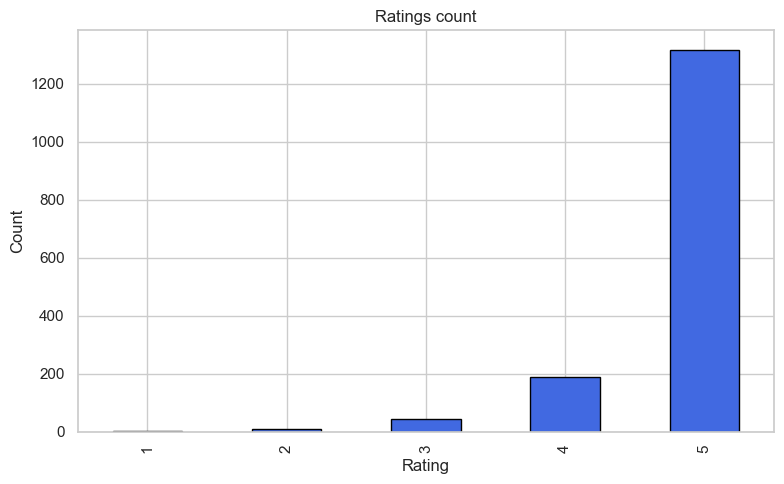

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set(style="whitegrid", font_scale=1.0)

# Ratings count
plt.figure(figsize=(8,5))
df["rating"].value_counts().sort_index().plot(kind="bar", color="royalblue", edgecolor="black")
plt.title("Ratings count")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

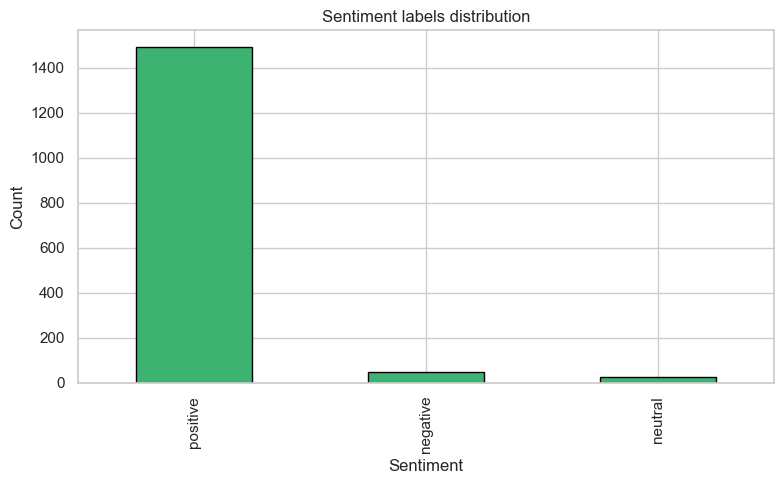

In [18]:
# Sentiment labels
plt.figure(figsize=(8,5))
df["sentiment_label"].value_counts().plot(kind="bar", color="mediumseagreen", edgecolor="black")
plt.title("Sentiment labels distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

C:\Users\Gowth\AppData\Local\Temp\ipykernel_18824\1993374864.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  temp["month"] = temp["date"].dt.to_period("M").dt.to_timestamp()


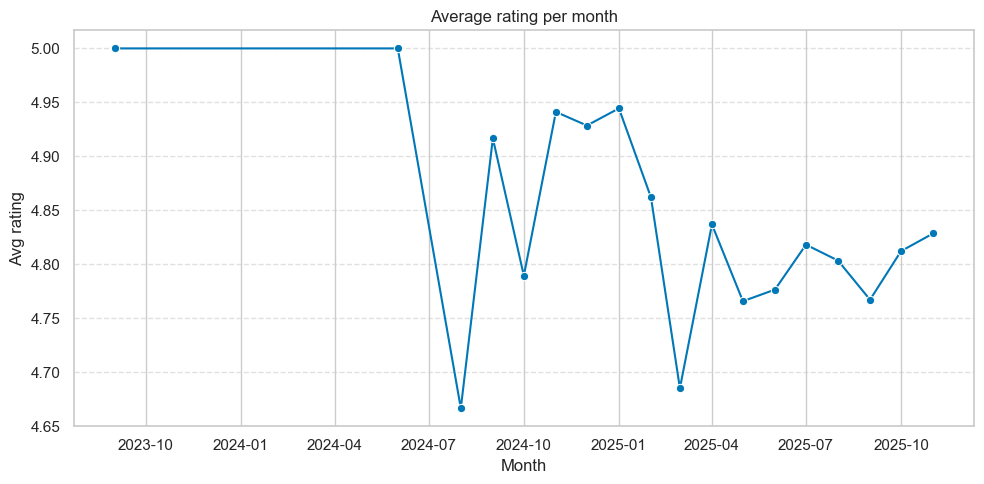

In [19]:
# Monthly average rating (if date is available)
if "date" in df.columns and df["date"].notna().any():
    temp = df.dropna(subset=["date"]).copy()
    temp["month"] = temp["date"].dt.to_period("M").dt.to_timestamp()
    monthly = temp.groupby("month")["rating"].mean().reset_index()

    plt.figure(figsize=(10,5))
    sns.lineplot(data=monthly, x="month", y="rating", marker="o", color="#0077B6")
    plt.title("Average rating per month")
    plt.xlabel("Month")
    plt.ylabel("Avg rating")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

C:\Users\Gowth\AppData\Local\Temp\ipykernel_18824\3830859195.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=theme_df, x="theme", y="count", palette="viridis")


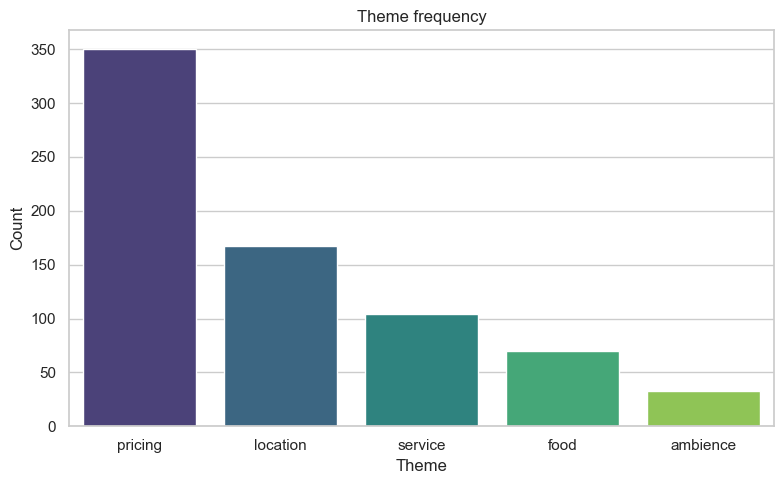

In [20]:
# Theme frequency
from collections import Counter

theme_counts = Counter(t for ts in df["themes"] for t in ts)
theme_df = pd.DataFrame(theme_counts.items(), columns=["theme","count"]).sort_values("count", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=theme_df, x="theme", y="count", palette="viridis")
plt.title("Theme frequency")
plt.xlabel("Theme")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Business tips per review

In [24]:
def improvement_tip(row):
    themes = set(row.get("themes", []))
    score = row.get("sentiment_score", 0)
    tips = []

    if "service" in themes and score < 0:  tips.append("🧑‍🍳 Improve staff responsiveness.")
    if "pricing" in themes and score < 0:  tips.append("💰 Review pricing and value communication.")
    if "ambience" in themes and score < 0: tips.append("🕯️ Enhance cleanliness/comfort.")
    if "food" in themes and score < 0:     tips.append("🍽️ Focus on consistency and taste.")
    if "location" in themes and score < 0: tips.append("📍 Clarify directions and parking.")

    if not tips and score < 0: tips.append("🔧 Address recurring complaints.")
    if not tips and score >= 0: tips.append("✅ Maintain strengths and monitor feedback.")

    return " ".join(tips)

df["business_tip"] = df.apply(improvement_tip, axis=1)
df[["text","sentiment_label","themes_str","business_tip","date"]].head(5)

,text,sentiment_label,themes_str,business_tip,date
0,•\tNo ticket needed: You don’t have to buy a t...,positive,"pricing, location",✅ Maintain strengths and monitor feedback.,2025-10-22 08:11:40+00:00
1,The Eiffel Tower is one of the most iconic lan...,positive,pricing,✅ Maintain strengths and monitor feedback.,2025-11-05 16:00:26+00:00
2,Great view from the top (actually 2nd floor is...,positive,,✅ Maintain strengths and monitor feedback.,2025-11-08 13:04:20+00:00
3,A Magical Day at the Eiffel Tower\n\nI visited...,positive,service,✅ Maintain strengths and monitor feedback.,2025-10-03 12:48:26+00:00
4,What a beautiful view. Going to the top was am...,positive,pricing,✅ Maintain strengths and monitor feedback.,2025-11-03 13:45:14+00:00


Save cleaned outputs

In [ ]:
if "date" in df.columns:
    df["date"] = df["date"].dt.tz_localize(None)

In [ ]:
CLEAN_PARQUET = "reviews_clean.parquet"
CLEAN_XLSX    = "reviews_clean.xlsx"

# Drop timezone info for Excel compatibility
if "date" in df.columns:
    df["date"] = df["date"].dt.tz_localize(None)

df.to_parquet(CLEAN_PARQUET, index=False)
df.to_excel(CLEAN_XLSX, index=False)

print(f"Saved: {CLEAN_PARQUET} and {CLEAN_XLSX} | Rows: {len(df)}")